In [200]:
import pandas as pd

df = pd.read_csv("data/51000-0058_en.csv")
df.head()

,year,month,value_code,value_label,Imports: Value index,Exports: Value index,Terms of trade
0,2019,January,EGW1,Live animals,129.2,105.5,109.5
1,2019,January,EGW2,Food of animal origin,101.7,99.9,99.3
2,2019,January,EGW3,Food of vegetable origin,89.7,85.9,102.6
3,2019,January,EGW4,Tea,alcoholic beverages,e,e
4,2019,January,EGW1-4,Food,92.4,93.7,103.2


We look at the Imports:Value index and Exports:Value index to compare the change in prices of goods/services compared to the previous year. To generate the graph in 8.5, we use the Terms of trade

In [201]:
df.set_index(['year', 'month'], inplace=True)
df.head()

value_code               value_label  Imports: Value index  \
year month                                                                
2019 January       EGW1              Live animals                 129.2   
     January       EGW2     Food of animal origin                 101.7   
     January       EGW3  Food of vegetable origin                  89.7   
     January       EGW4                       Tea   alcoholic beverages   
     January     EGW1-4                      Food                  92.4   

             Exports: Value index Terms of trade  
year month                                        
2019 January                105.5          109.5  
     January                 99.9           99.3  
     January                 85.9          102.6  
     January                    e              e  
     January                 93.7          103.2

105.6 93.0 101.0 2.9355375917165416


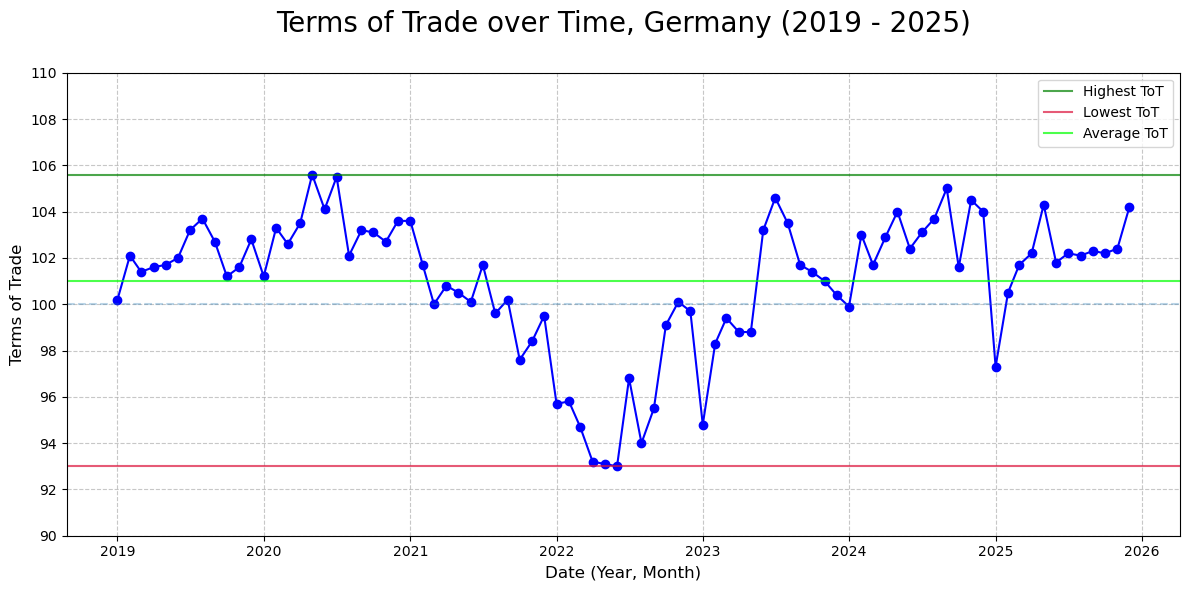

In [349]:
import matplotlib.pyplot as plt

x = df[df['value_label'] == 'Total']["Terms of trade"]
x.index = pd.to_datetime([f"{year} {month}" for year, month in x.index], format="%Y %B")

print(
    x.values.astype(float).max(),
    x.values.astype(float).min(),
    x.values.astype(float).mean(),
    x.values.astype(float).std()
)

plt.figure(figsize=(12, 6))
# # x.plot(color='blue', marker='o', linestyle='-')
plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-')
plt.ylim(90, 110)
plt.yticks(range(90, 111, 2))
plt.axhline(y=100, alpha=0.3, linestyle='--')
plt.axhline(y=x.values.astype(float).max(), alpha=0.7, color='green', linestyle='-', label='Highest ToT')
plt.axhline(y=x.values.astype(float).min(), alpha=0.7, color='crimson', linestyle='-', label='Lowest ToT')
plt.axhline(y=x.values.astype(float).mean(), alpha=0.7, color='lime', linestyle='-', label='Average ToT')
plt.title("Terms of Trade over Time, Germany (2019 - 2025)\n", fontsize=20)
plt.xlabel("Date (Year, Month)", fontsize=12)
plt.ylabel("Terms of Trade", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()

In [280]:
import numpy as np

df['value_label'].values

array(['Live animals', 'Food of animal origin',
       'Food of vegetable origin', ..., 'Industrial products',
       'Other unallocated products', 'Total'], dtype=object)

In [286]:
cols_to_convert = ['Imports: Value index', 'Exports: Value index', 'Terms of trade']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.head()

value_code               value_label  Imports: Value index  \
year month                                                                
2019 January       EGW1              Live animals                 129.2   
     January       EGW2     Food of animal origin                 101.7   
     January       EGW3  Food of vegetable origin                  89.7   
     January       EGW4                       Tea                   NaN   
     January     EGW1-4                      Food                  92.4   

              Exports: Value index  Terms of trade  
year month                                          
2019 January                 105.5           109.5  
     January                  99.9            99.3  
     January                  85.9           102.6  
     January                   NaN             NaN  
     January                  93.7           103.2

In [287]:
import pandas as pd

# 1. Ensure 'Terms of trade' is numeric (cleaning any text like "e" or "N/A")
df['Terms of trade'] = pd.to_numeric(df['Terms of trade'], errors='coerce')

# 2. Pivot the DataFrame
# This makes your rows the Dates (year & month) and your columns the Items (value_label)
pivot_tot = df.pivot_table(
    index=['year', 'month'], 
    columns='value_label', 
    values='Terms of trade'
)

# 3. Calculate the correlation of every column against the 'Total' column
# corrwith() calculates pairwise correlation between rows or columns
item_correlations = pivot_tot.corrwith(pivot_tot['Total'])

# 4. Clean up the results: sort them from strongest to weakest correlation
item_correlations = item_correlations.sort_values(ascending=False)

# Optional: Drop the 'Total' vs 'Total' correlation (which will always be 1.0)
item_correlations = item_correlations.drop('Total', errors='ignore')

# Display the results
print("Correlation of each sector's Terms of Trade with the Total Terms of Trade:")
print(item_correlations)

Correlation of each sector's Terms of Trade with the Total Terms of Trade:
value_label
Industrial products           0.983629
Finished goods                0.669521
Food of vegetable origin      0.523943
Food                          0.433623
End products                  0.424366
Intermediate products         0.380126
Semi-finished goods           0.234220
Other unallocated products    0.221804
Food of animal origin         0.059721
Raw materials                 0.040808
Live animals                 -0.408427
dtype: float64


Correlation analysis between the various total terms of trade and Germany's Total Terms of Trade shows that industrial products and finished goods show a higher degree of positive correlation with total terms of trade. On the other hand, live animals show moderate negative correlation with total terms of trade. Therefore, we plot a graph between Industrial products, Finished goods, and Live animals.

Text(108.09722222222221, 0.5, 'Terms of Trade')

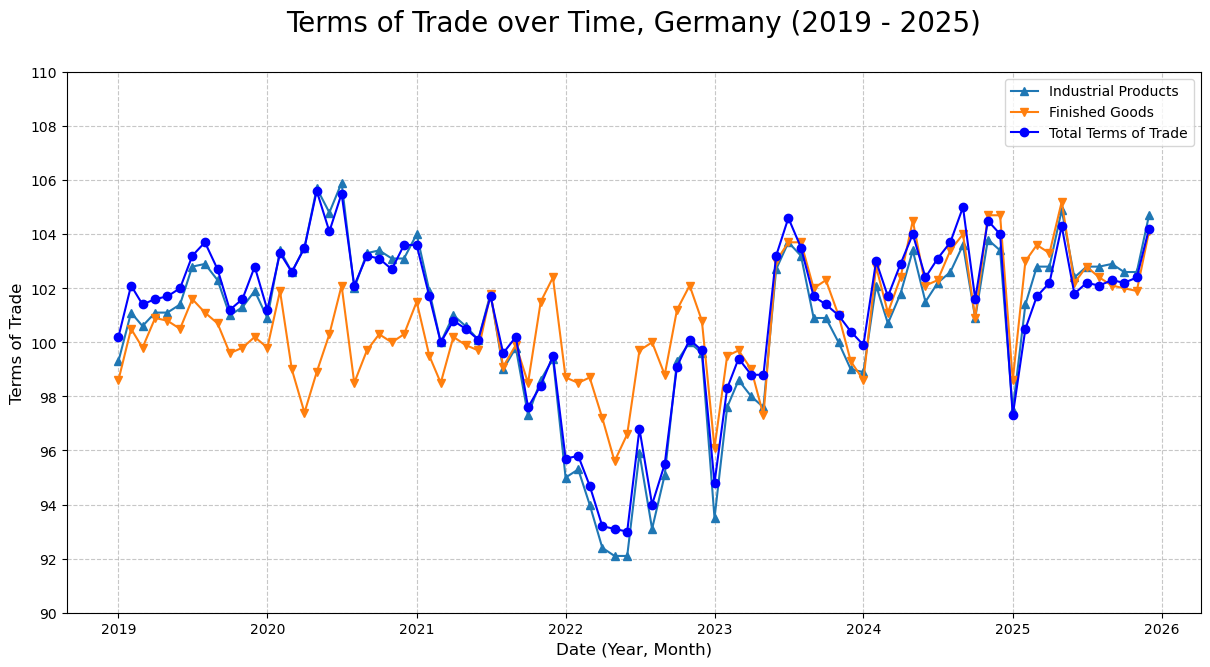

In [342]:
ip_exports_values = df[df['value_label'] == 'Industrial products']["Exports: Value index"].values.astype(float)
ip_imports_values = df[df['value_label'] == 'Industrial products']["Terms of trade"].values.astype(float)

fg_exports_values = df[df['value_label'] == 'Finished goods']["Exports: Value index"].values.astype(float)
fg_imports_values = df[df['value_label'] == 'Finished goods']["Terms of trade"].values.astype(float)

la_tot = df[df['value_label'] == 'Live animals']['Terms of trade'].values.astype(float)

plt.figure(figsize=(12, 6))
plt.ylim(90, 110)
plt.yticks(range(90, 111, 2))


plt.plot(x.index, ip_imports_values, marker="^", label="Industrial Products")
plt.plot(x.index, fg_imports_values, marker="v", label="Finished Goods")
plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Total Terms of Trade")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.title("Terms of Trade over Time, Germany (2019 - 2025)\n", fontsize=20)
plt.xlabel("Date (Year, Month)", fontsize=12)
plt.ylabel("Terms of Trade", fontsize=12)

Text(108.09722222222221, 0.5, 'Value Index')

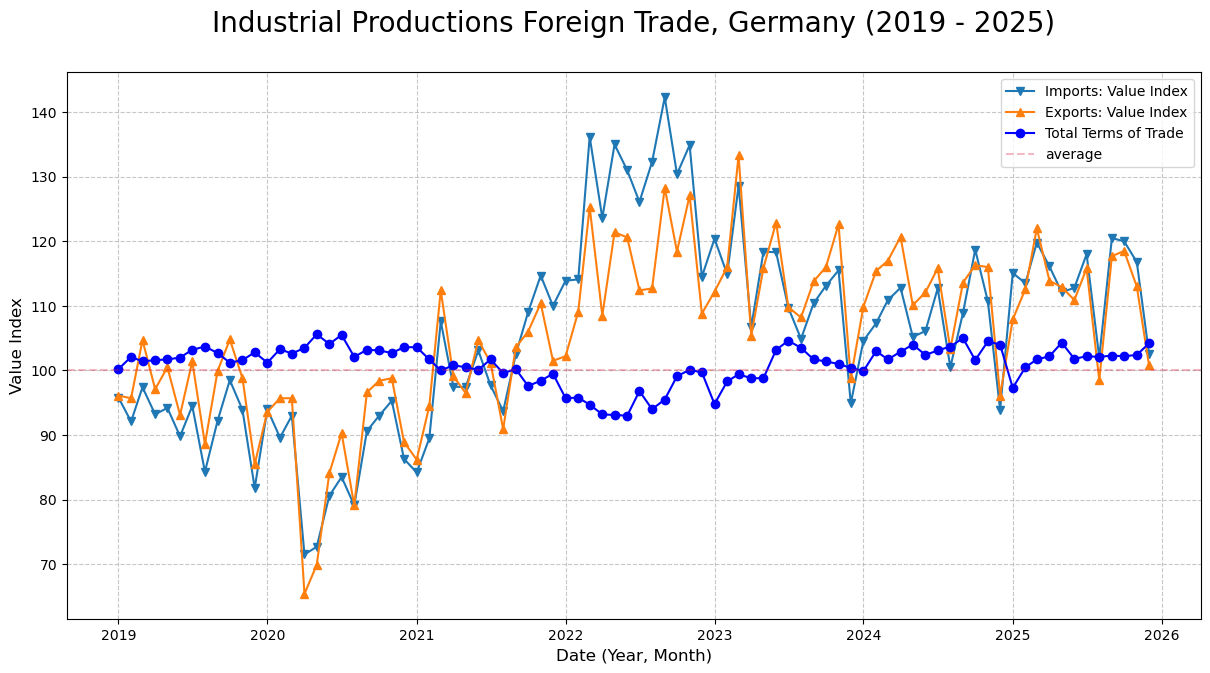

In [343]:
ip_exports_values = df[df['value_label'] == 'Industrial products']["Exports: Value index"].values.astype(float)
ip_imports_values = df[df['value_label'] == 'Industrial products']["Imports: Value index"].values.astype(float)

plt.figure(figsize=(12, 6))
plt.plot(x.index, ip_imports_values, marker="v", label="Imports: Value Index")
plt.plot(x.index, ip_exports_values, marker="^", label="Exports: Value Index")
plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Total Terms of Trade")
plt.axhline(y=100, alpha=0.3, color='crimson', linestyle='--', label='average')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.title("Industrial Productions Foreign Trade, Germany (2019 - 2025)\n", fontsize=20)
plt.xlabel("Date (Year, Month)", fontsize=12)
plt.ylabel("Value Index", fontsize=12)


Text(108.09722222222221, 0.5, 'Value Index')

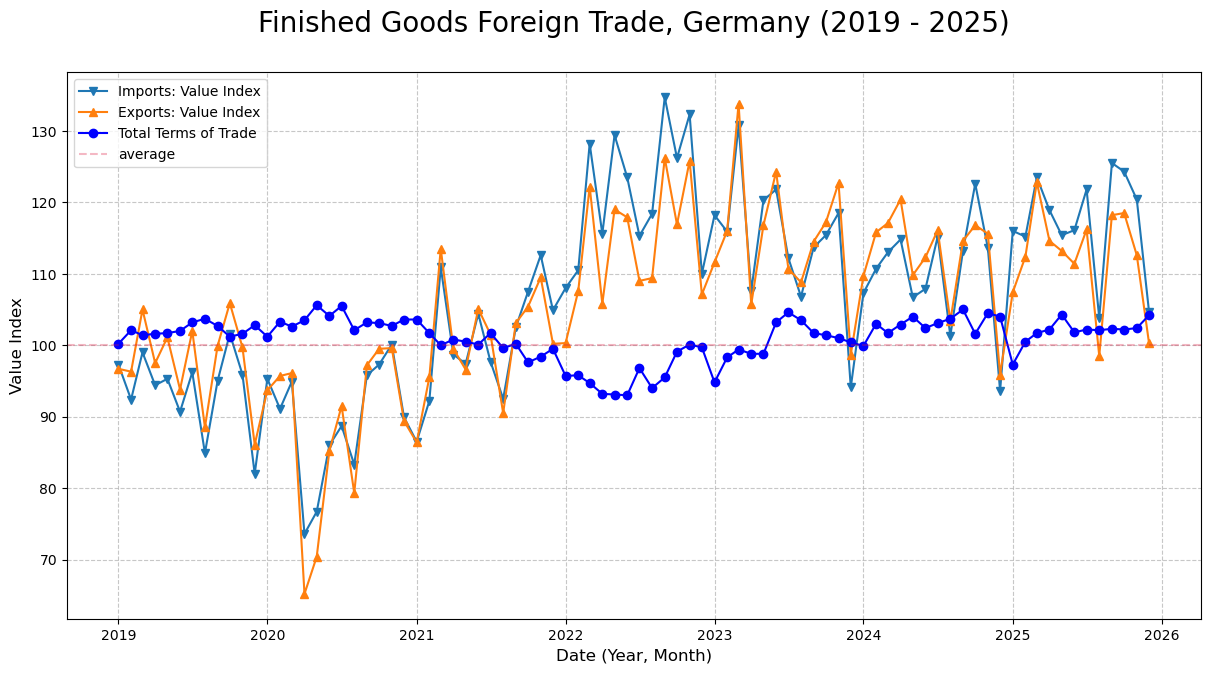

In [344]:
ip_exports_values = df[df['value_label'] == 'Finished goods']["Exports: Value index"].values.astype(float)
ip_imports_values = df[df['value_label'] == 'Finished goods']["Imports: Value index"].values.astype(float)

plt.figure(figsize=(12, 6))
plt.plot(x.index, ip_imports_values, marker="v", label="Imports: Value Index")
plt.plot(x.index, ip_exports_values, marker="^", label="Exports: Value Index")
plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Total Terms of Trade")
plt.axhline(y=100, alpha=0.3, color='crimson', linestyle='--', label='average')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.title("Finished Goods Foreign Trade, Germany (2019 - 2025)\n", fontsize=20)
plt.xlabel("Date (Year, Month)", fontsize=12)
plt.ylabel("Value Index", fontsize=12)
